<a href="https://colab.research.google.com/github/shreyankaul/scaler/blob/main/yulu_sk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement

Yulu is India’s leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting.

Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient!

Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.

The company wants to know:

- Which variables are significant in predicting the demand for shared electric cycles in the Indian market?
- How well those variables describe the electric cycle demands

# Importing Data and Python Libraries

In [91]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway
from scipy.stats import kruskal
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings('ignore')

In [92]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv?1642089089 -O yulu_data.csv

--2026-05-21 09:13:12--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv?1642089089
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 13.225.41.5, 13.225.41.45, 13.225.41.18, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|13.225.41.5|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 648353 (633K) [text/plain]
Saving to: ‘yulu_data.csv’

yulu_data.csv       100%[===================>] 633.16K  --.-KB/s    in 0.05s   

2026-05-21 09:13:12 (13.2 MB/s) - ‘yulu_data.csv’ saved [648353/648353]



#Data Exploration and Data Cleaning

In [93]:
df = pd.read_csv('/content/yulu_data.csv')

In [94]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [95]:
df.shape

(10886, 12)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


**Observations**

- The dataset contains 10,886 observations and 12 variables.

- The dataset includes both categorical and continuous variables.

- No missing values are present in the dataset.

- The 'datetime' column is initially stored as an object datatype and requires conversion into datetime format.

In [97]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [98]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


**Statistical Summary Insights**

- Temperature and humidity variables show substantial variation across observations.

- Bike rental count ranges from very low to extremely high values, indicating possible skewness and outliers.

- The dataset contains both casual and registered user counts, which together form the total rental count.

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df['datetime'] = pd.to_datetime(df['datetime'])

**Feature Engineering:** Additional temporal features such as year, month, and hour are extracted from the datetime column to enable deeper time-based analysis.

In [101]:
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour

In [102]:
cat_cols = ['season', 'holiday', 'workingday', 'weather']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  category      
 3   workingday  10886 non-null  category      
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  hour        10886 non-null  int32         
dtypes: category(4), datetime64[ns](1), float64(3), int32(3), int64(4)
memo

In [104]:
df['season'] = df['season'].replace({
    1:'Spring',
    2:'Summer',
    3:'Fall',
    4:'Winter'})

df['holiday'] = df['holiday'].replace({
    0:'No',
    1:'Yes'})

df['workingday'] = df['workingday'].replace({
    0:'No',
    1:'Yes'})

df['weather'] = df['weather'].replace({
    1:'Clear',
    2:'Mist + Cloudy',
    3:'Light Rain/Snow',
    4:'Heavy Rain'})

In [105]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,hour
0,2011-01-01 00:00:00,Spring,No,No,Clear,9.84,14.395,81,0.0,3,13,16,2011,1,0
1,2011-01-01 01:00:00,Spring,No,No,Clear,9.02,13.635,80,0.0,8,32,40,2011,1,1
2,2011-01-01 02:00:00,Spring,No,No,Clear,9.02,13.635,80,0.0,5,27,32,2011,1,2
3,2011-01-01 03:00:00,Spring,No,No,Clear,9.84,14.395,75,0.0,3,10,13,2011,1,3
4,2011-01-01 04:00:00,Spring,No,No,Clear,9.84,14.395,75,0.0,0,1,1,2011,1,4


#Univariate Analysis
**Continuous Variables Analysis**

**Histogram**

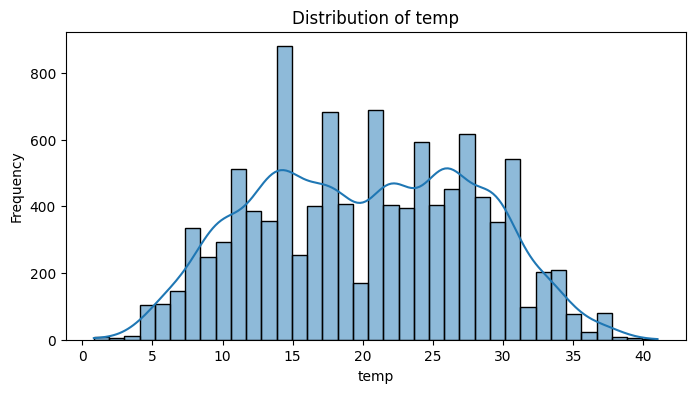

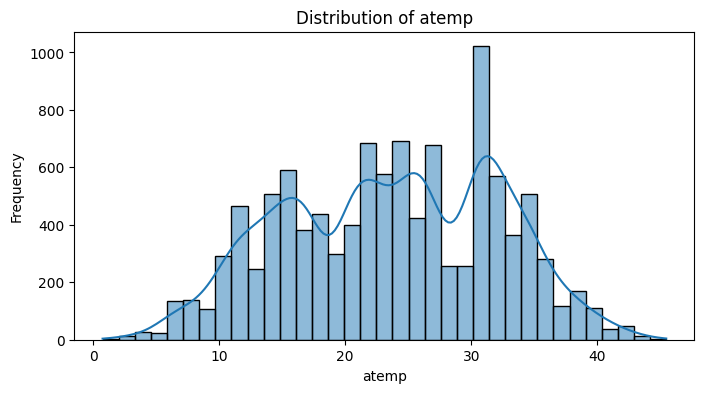

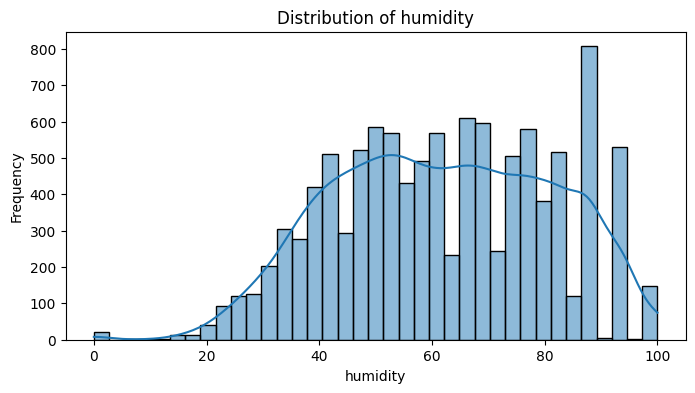

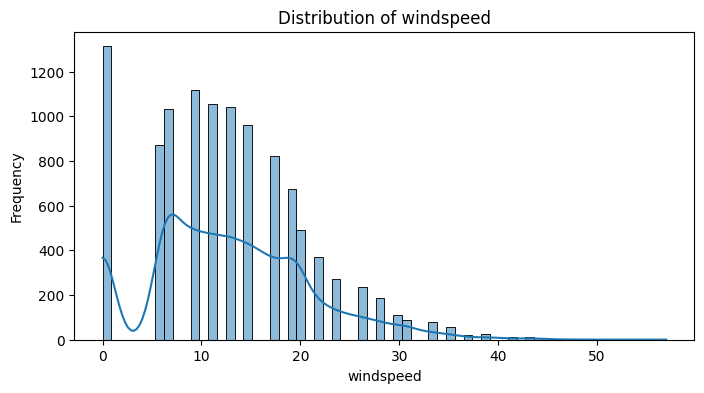

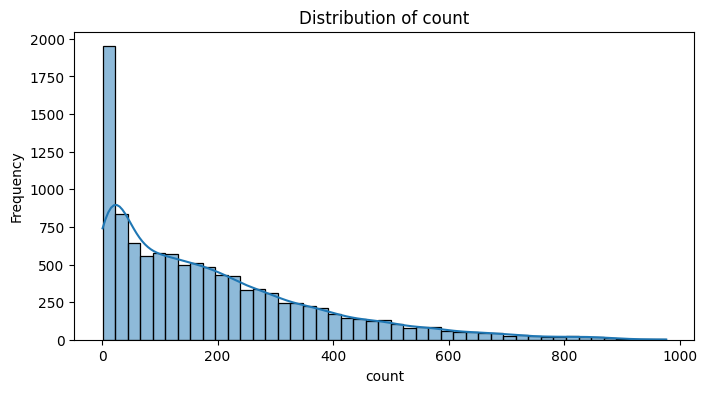

In [106]:
cont_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'count']

for col in cont_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], kde=True)

    plt.title(f'Distribution of {col}')

    plt.xlabel(col)

    plt.ylabel('Frequency')

    plt.show()

**Observations from Histogram Analysis**

- The variables 'temp' and 'atemp' show approximately bell-shaped distributions, indicating relatively balanced temperature observations across the dataset.

- 'humidity' values are concentrated mostly between moderate to high levels, suggesting that bike rental activity frequently occurs under humid conditions.

- 'windspeed' is positively skewed, with most observations concentrated at lower windspeed values and relatively fewer observations at extremely high wind speeds.

- The target variable 'count' is heavily right-skewed, indicating that most time periods experience moderate bike rental demand while a small number of observations show extremely high rental counts.

- The skewness observed in 'count' suggests that the data may not follow a normal distribution, which becomes important while selecting appropriate statistical tests later in the analysis.

**Boxplot**

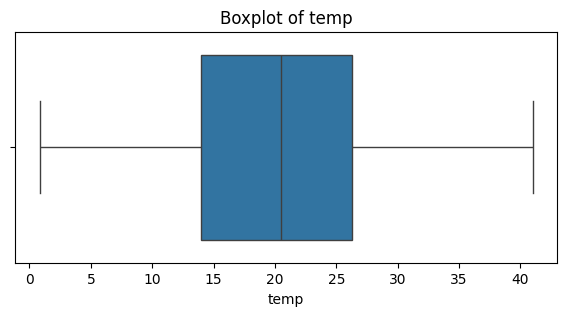

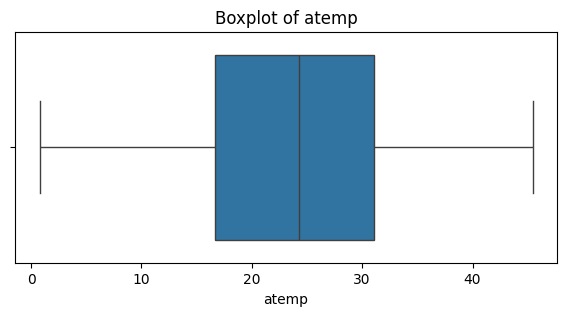

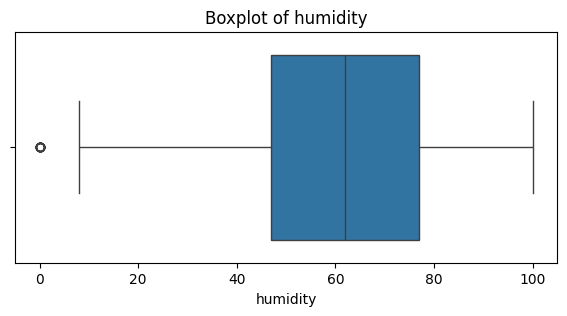

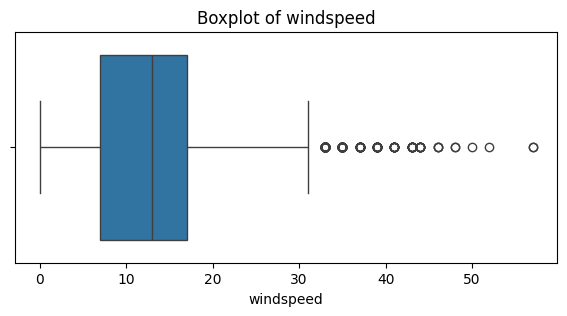

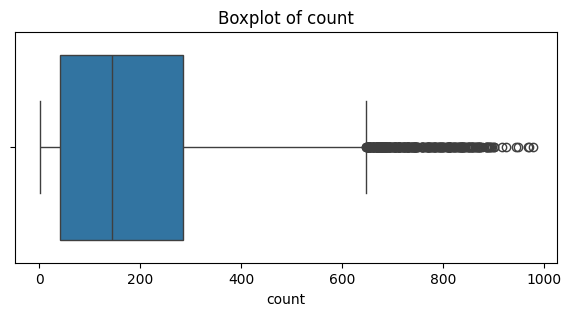

In [107]:
for col in cont_cols:

    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

**Observations from Boxplot Analysis**

- The variables 'temp' and 'atemp' do not show significant outliers and appear relatively symmetrically distributed.

- 'humidity' shows a few minor lower-end outliers, but overall the distribution remains fairly stable.

- 'windspeed' contains multiple upper-end outliers, indicating that extremely high windspeed conditions occur infrequently.

- The target variable 'count' contains a large number of upper-end outliers and exhibits substantial variability in bike rental demand.

- The presence of extreme values and skewness in 'count' further suggests that the variable may not follow a normal distribution.

- High rental outliers may correspond to peak commuting hours, favorable weather conditions, or seasonal demand surges.

**Categorical Variable Analysis**

**Countplots**

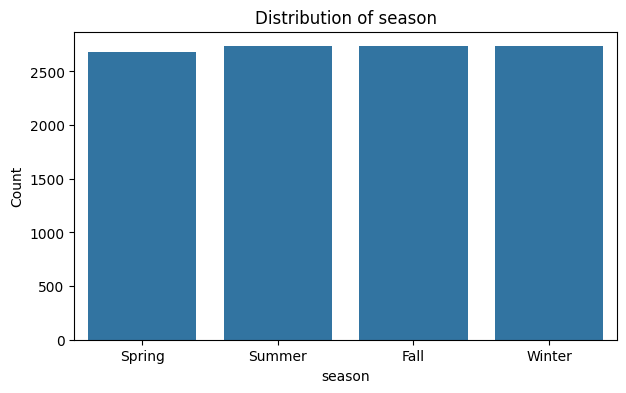

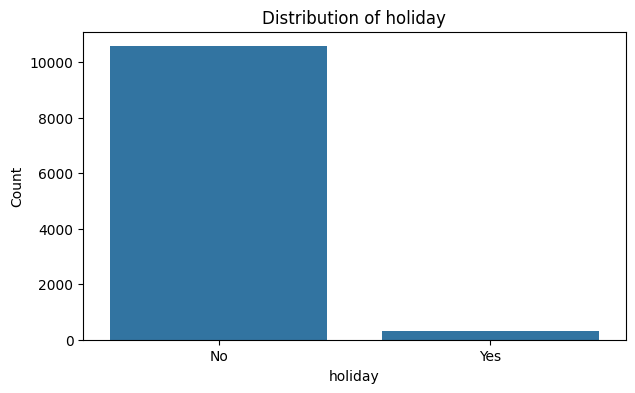

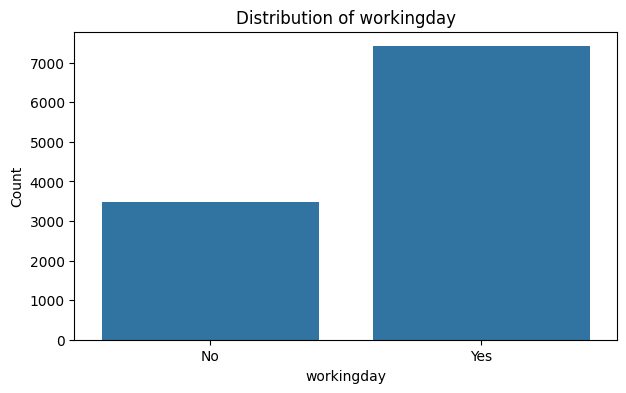

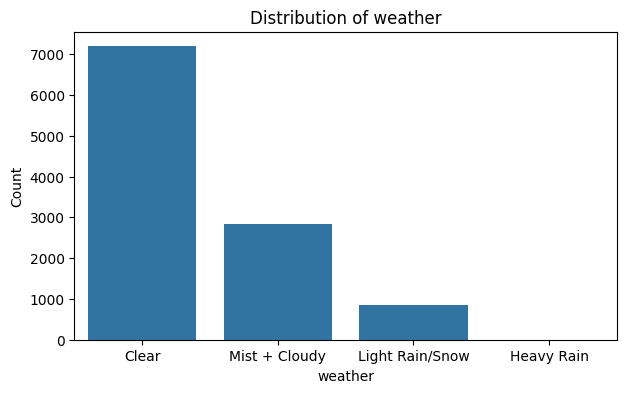

In [108]:
cat_cols = ['season', 'holiday', 'workingday', 'weather']

for col in cat_cols:

    plt.figure(figsize=(7,4))

    sns.countplot(x=col, data=df)

    plt.title(f'Distribution of {col}')

    plt.xlabel(col)

    plt.ylabel('Count')

    plt.show()

**Observations from Categorical Variable Analysis**

- The dataset is fairly balanced across all four seasons, allowing reliable seasonal comparisons.

- Non-holiday observations are significantly higher than holiday observations, indicating that most rental activity was recorded during regular days.

- Working days occur more frequently than non-working days in the dataset.

- Most observations belong to clear weather conditions, while severe weather conditions occur very rarely.

- The low frequency of extreme weather conditions may influence statistical testing and demand analysis across weather categories.

#Bivariate Analysis

**Working Day vs Count**

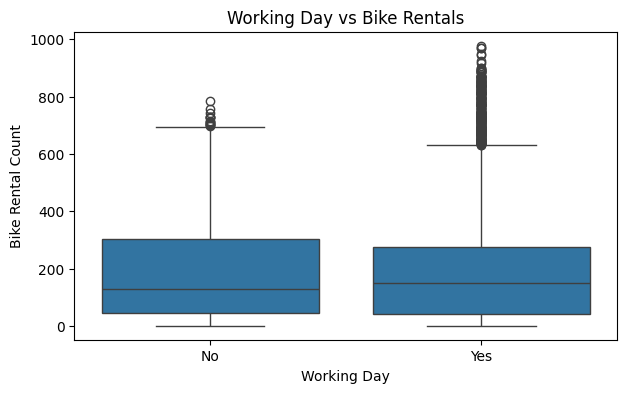

In [109]:
plt.figure(figsize=(7,4))

sns.boxplot(x='workingday', y='count', data=df)

plt.title('Working Day vs Bike Rentals')

plt.xlabel('Working Day')

plt.ylabel('Bike Rental Count')

plt.show()

**Observation**

Bike rental demand appears slightly higher during working days compared to non-working days, indicating that commuting demand may contribute significantly to Yulu’s rentals.

**Season vs Count**

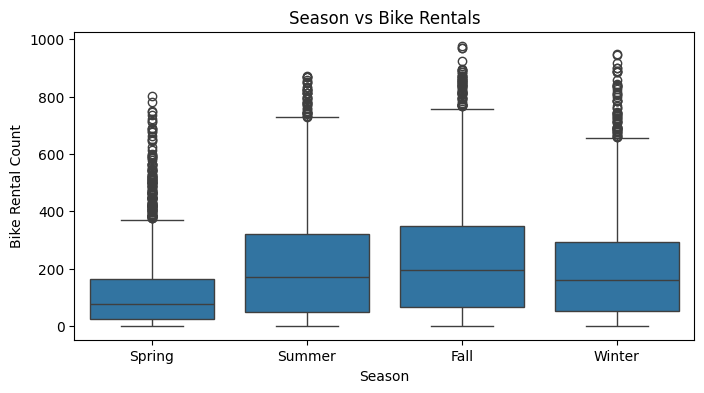

In [110]:
plt.figure(figsize=(8,4))

sns.boxplot(x='season', y='count', data=df)

plt.title('Season vs Bike Rentals')

plt.xlabel('Season')

plt.ylabel('Bike Rental Count')

plt.show()

**Observation**

Bike rental demand varies across seasons. Higher median rentals are observed during Fall and Summer seasons, suggesting that favorable climatic conditions positively influence bike usage.

**Weather vs Count**

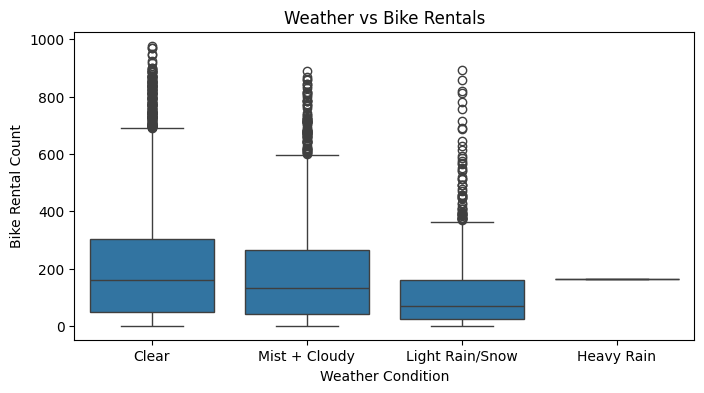

In [111]:
plt.figure(figsize=(8,4))

sns.boxplot(x='weather', y='count', data=df)

plt.title('Weather vs Bike Rentals')

plt.xlabel('Weather Condition')

plt.ylabel('Bike Rental Count')

plt.show()

**Observation**

Bike rental demand decreases significantly under unfavorable weather conditions. Clear weather conditions show the highest rental demand, while rainy or snowy conditions show comparatively lower rentals.

#Correlation Analysis
**Correlation Heatmap**

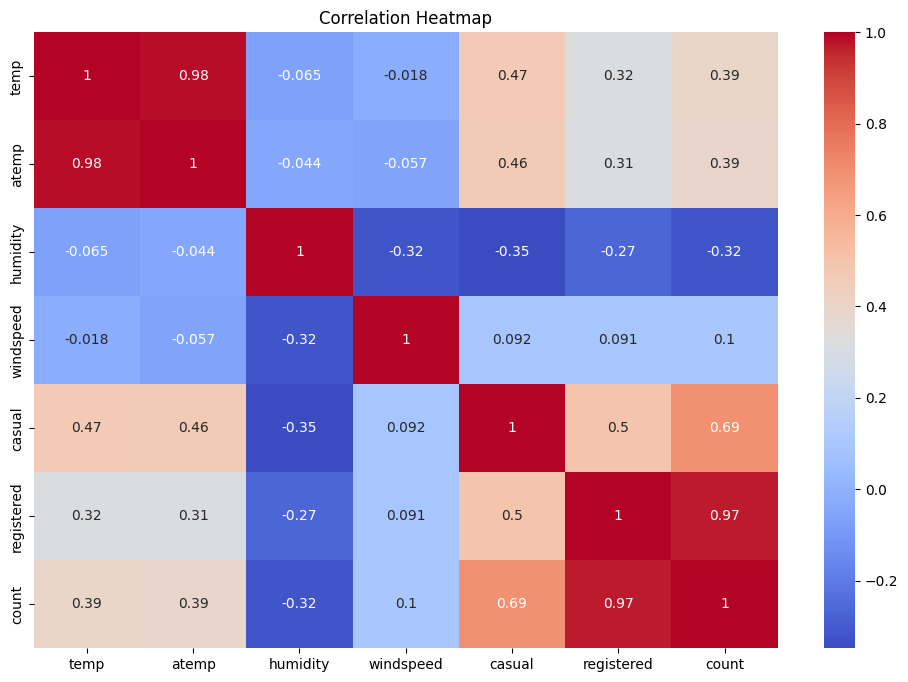

In [112]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=['int64', 'float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

**Observations from Correlation Analysis**

- 'temp' and 'atemp' show extremely high correlation, indicating strong multicollinearity between the two temperature-related variables.

- 'count' is strongly associated with both 'registered' and 'casual' users since total bike rentals are derived from these two user categories.

- Humidity shows a moderate negative relationship with bike rentals, suggesting that higher humidity levels may reduce bike usage.

- Temperature variables exhibit a favorable relationship with bike rental demand, indicating that comfortable weather conditions encourage bike usage.

- Windspeed shows a comparatively weak relationship with rental demand, suggesting limited direct influence on bike rentals.

In [113]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,hour
0,2011-01-01 00:00:00,Spring,No,No,Clear,9.84,14.395,81,0.0,3,13,16,2011,1,0
1,2011-01-01 01:00:00,Spring,No,No,Clear,9.02,13.635,80,0.0,8,32,40,2011,1,1
2,2011-01-01 02:00:00,Spring,No,No,Clear,9.02,13.635,80,0.0,5,27,32,2011,1,2
3,2011-01-01 03:00:00,Spring,No,No,Clear,9.84,14.395,75,0.0,3,10,13,2011,1,3
4,2011-01-01 04:00:00,Spring,No,No,Clear,9.84,14.395,75,0.0,0,1,1,2011,1,4


#Distribution & Normality Analysis

**Distribution of Count**

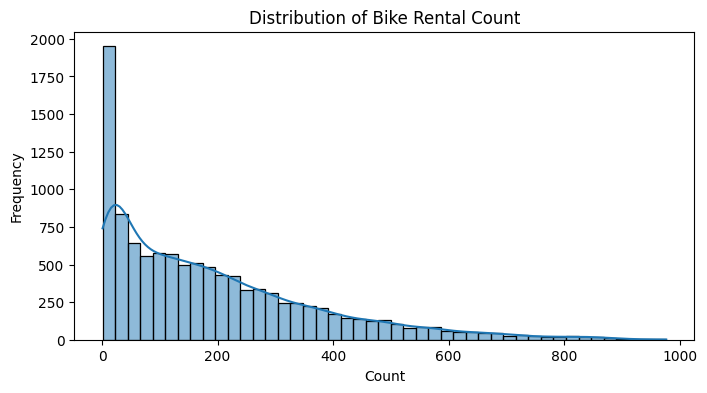

In [114]:
plt.figure(figsize=(8,4))

sns.histplot(df['count'], kde=True)

plt.title('Distribution of Bike Rental Count')

plt.xlabel('Count')

plt.ylabel('Frequency')

plt.show()

**Boxplot of Count**

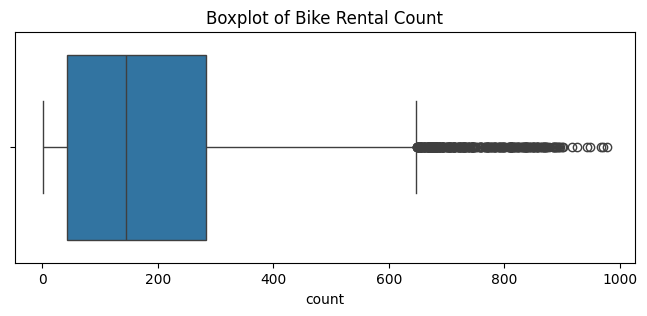

In [115]:
plt.figure(figsize=(8,3))

sns.boxplot(x=df['count'])

plt.title('Boxplot of Bike Rental Count')

plt.show()

**Log Transformation of count variable**

In [116]:
df['log_count'] = np.log1p(df['count'])

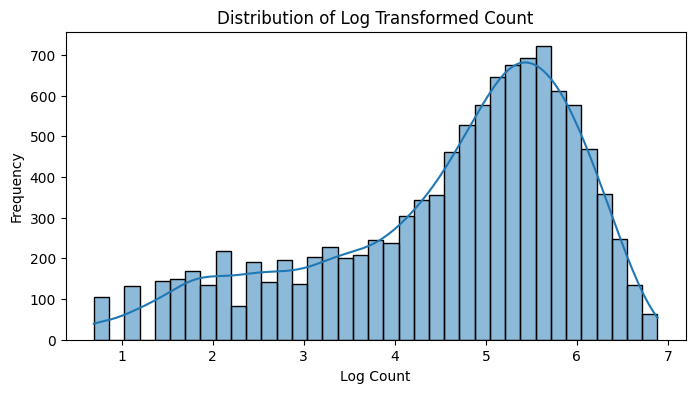

In [117]:
plt.figure(figsize=(8,4))

sns.histplot(df['log_count'], kde=True)

plt.title('Distribution of Log Transformed Count')

plt.xlabel('Log Count')

plt.ylabel('Frequency')

plt.show()

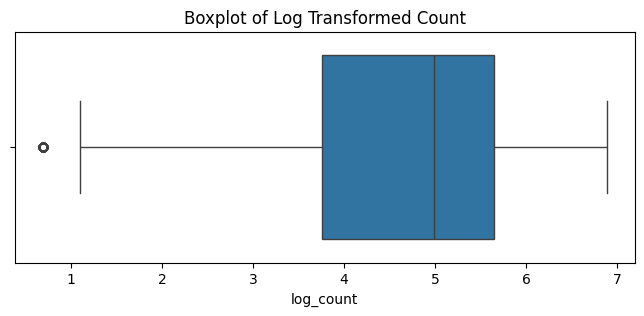

In [118]:
plt.figure(figsize=(8,3))

sns.boxplot(x=df['log_count'])

plt.title('Boxplot of Log Transformed Count')

plt.show()

**Observations from Distribution & Normality Analysis**

- The original 'count' variable exhibits strong positive skewness, indicating that bike rental demand is not normally distributed.

- The boxplot of 'count' confirms the presence of several upper-end outliers representing periods of unusually high rental demand.

- Log transformation significantly reduces skewness and stabilizes the distribution of the target variable.

- The transformed distribution appears comparatively more symmetric and closer to a normal distribution.

- The reduction in extreme values after transformation indicates improved distributional stability.

- These findings are important while evaluating statistical assumptions for hypothesis testing techniques such as t-tests and ANOVA.

#Hypothesis Testing

**1. Two Sample T-Test: Working Day vs Bike Rentals**

- Business Question: Does the number of bike rentals differ significantly between working days and non-working days?

Hypotheses:

- **Null Hypothesis (H0):** The average bike rental count is the same for working and non-working days.

- **Alternate Hypothesis (H1):** The average bike rental count differs between working and non-working days.

In [119]:
working_day = df[df['workingday'] == 'Yes']['count']

non_working_day = df[df['workingday'] == 'No']['count']

Assumption Check: Normality

In [120]:
from scipy.stats import shapiro

shapiro(working_day.sample(500))

shapiro(non_working_day.sample(500))

ShapiroResult(statistic=np.float64(0.8764071582587816), pvalue=np.float64(1.6181373436398536e-19))

**Observation**

- The Shapiro-Wilk test produces a very small p-value, indicating that the rental count distribution deviates from normality.

- However, due to the large sample size, the Central Limit Theorem allows us to proceed with parametric hypothesis testing.



Assumption Check: Equal Variance

In [121]:
from scipy.stats import levene

levene(working_day, non_working_day)

LeveneResult(statistic=np.float64(0.004972848886504472), pvalue=np.float64(0.9437823280916695))

**Observation**

- Levene’s Test produces a p-value greater than 0.05, indicating that the variances of the two groups are approximately equal.

Performing Two Sample T-Test

In [122]:
from scipy.stats import ttest_ind

ttest_ind(
    working_day,
    non_working_day,
    equal_var=False
)

TtestResult(statistic=np.float64(1.2362580418223226), pvalue=np.float64(0.21640312280695098), df=np.float64(7176.288413844308))

**Inference**
- Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis.

- This indicates that there is no statistically significant difference in average bike rental demand between working days and non-working days.

- The result suggests that overall bike rental demand remains relatively similar across both categories.

**2. ANOVA / Kruskal-Wallis Test: Season vs Bike Rental Demand**

- Business Question: Does bike rental demand differ significantly across different seasons?

Hypotheses:

- **Null Hypothesis (H0):** Average bike rental demand is the same across all seasons.

- **Alternate Hypothesis (H1):** Average bike rental demand differs across seasons.

In [123]:
spring = df[df['season'] == 'Spring']['count']

summer = df[df['season'] == 'Summer']['count']

fall = df[df['season'] == 'Fall']['count']

winter = df[df['season'] == 'Winter']['count']

Assumption Check: Normality

In [124]:
shapiro(spring.sample(500))

shapiro(summer.sample(500))

shapiro(fall.sample(500))

shapiro(winter.sample(500))

ShapiroResult(statistic=np.float64(0.9038300698774792), pvalue=np.float64(3.2087339125542854e-17))

**Observation**

- The Shapiro-Wilk test produces very small p-values across seasonal groups, indicating that bike rental demand does not strictly follow normal distribution assumptions.

Assumption Check: Equal Variance

In [125]:
levene(spring, summer, fall, winter)

LeveneResult(statistic=np.float64(187.7706624026276), pvalue=np.float64(1.0147116860043298e-118))

**Observation**

- Levene’s Test produces a p-value less than 0.05, indicating that equal variance assumptions across seasonal groups are violated.

Performing One-Way ANOVA

In [126]:
f_oneway(spring, summer, fall, winter)

F_onewayResult(statistic=np.float64(236.94671081032098), pvalue=np.float64(6.164843386499654e-149))

**Inference**

- Since the p-value is significantly lower than the significance level of 0.05, the null hypothesis is rejected.

- This indicates that bike rental demand differs significantly across seasons.

- Seasonal conditions have a strong influence on Yulu’s rental demand patterns.

- Favorable weather and environmental conditions during certain seasons likely contribute to higher bike usage.

Performing Kruskal-Wallis Test

In [127]:
kruskal(spring, summer, fall, winter)

KruskalResult(statistic=np.float64(699.6668548181988), pvalue=np.float64(2.479008372608633e-151))

**Observation**

The Kruskal-Wallis test produces a p-value significantly lower than 0.05, indicating statistically significant differences in bike rental demand across seasons.

This confirms the ANOVA findings using a non-parametric approach that does not assume normality.

**3. Weather vs Bike Rental Demand**

- Business Question: Does bike rental demand differ significantly across different weather conditions?

Hypotheses:

- **Null Hypothesis (H0):** Average bike rental demand is the same across all weather conditions.

- **Alternate Hypothesis (H1):** Average bike rental demand differs across weather conditions.

In [128]:
clear = df[df['weather'] == 'Clear']['count']

mist = df[df['weather'] == 'Mist + Cloudy']['count']

light_rain = df[df['weather'] == 'Light Rain/Snow']['count']

Assumption Check: Normality

In [129]:
shapiro(clear.sample(500))

shapiro(mist.sample(500))

shapiro(light_rain.sample(500))

ShapiroResult(statistic=np.float64(0.763427778252689), pvalue=np.float64(3.453915377990922e-26))

**Observation**

- The Shapiro-Wilk test produces very small p-values across weather groups, indicating that bike rental demand does not strictly follow normal distribution assumptions.

Assumption Check: Equal Variance

In [130]:
levene(clear, mist, light_rain)

LeveneResult(statistic=np.float64(81.67574924435011), pvalue=np.float64(6.198278710731511e-36))

**Observation**

- Levene’s Test produces a p-value less than 0.05, indicating that equal variance assumptions across weather groups are violated.

Performing One-Way ANOVA

In [131]:
f_oneway(clear, mist, light_rain)

F_onewayResult(statistic=np.float64(98.28356881946705), pvalue=np.float64(4.976448509904196e-43))

**Inference**

- Since the p-value is significantly lower than the significance level of 0.05, the null hypothesis is rejected.

- This indicates that bike rental demand differs significantly across weather conditions.

- Favorable weather conditions encourage higher bike rental demand, while adverse weather conditions reduce bike usage.

- Weather appears to be one of the strongest environmental factors affecting Yulu’s rental demand.

Performing Kruskal-Wallis Test

In [132]:
kruskal(clear, mist, light_rain)

KruskalResult(statistic=np.float64(204.95566833068537), pvalue=np.float64(3.122066178659941e-45))

**Observation**

- The Kruskal-Wallis test also produces a p-value significantly lower than 0.05, indicating statistically significant differences in bike rental demand across weather conditions.

- This validates the ANOVA findings using a non-parametric approach that does not require normality assumptions.

**4. Chi-Square Test: Weather vs Season**

- Business Question: Is weather condition dependent on season?

Hypotheses

- **Null Hypothesis (H0):** Weather condition and season are independent of each other.

- **Alternate Hypothesis (H1):** Weather condition and season are dependent on each other.

Creating Contingency Table

In [133]:
chi_df = df[df['weather'] != 'Heavy Rain']

In [134]:
contingency_table = pd.crosstab(chi_df['season'],chi_df['weather'])

contingency_table

weather,Clear,Mist + Cloudy,Light Rain/Snow
season,,,
Spring,1759,715,211
Summer,1801,708,224
Fall,1930,604,199
Winter,1702,807,225


Performing Chi-Square Test

In [135]:
chi2_contingency(contingency_table)

Chi2ContingencyResult(statistic=np.float64(46.10145731073249), pvalue=np.float64(2.8260014509929343e-08), dof=6, expected_freq=array([[1774.04869086,  699.06201194,  211.8892972 ],
       [1805.76352779,  711.55920992,  215.67726229],
       [1805.76352779,  711.55920992,  215.67726229],
       [1806.42425356,  711.81956821,  215.75617823]]))

**Inference**

- Since the p-value is significantly lower than the significance level of 0.05, the null hypothesis is rejected.

- This indicates that weather conditions and seasons are statistically dependent on each other.

- Seasonal variations significantly influence weather patterns in the dataset.

- Certain weather conditions occur more frequently during specific seasons.

# Overall Insights

- Bike rental demand is strongly influenced by environmental and seasonal factors.

- Temperature variables show positive association with bike rental demand, while humidity shows a negative relationship.

- Working day status does not create a statistically significant difference in rental demand.

- Seasonal variations significantly impact bike rental demand patterns.

- Weather conditions also have a strong effect on bike rentals, with favorable weather encouraging higher usage.

- Distribution analysis revealed that rental demand data is positively skewed and contains outliers.

- Log transformation improved the distributional characteristics of the target variable.

- Statistical tests confirmed significant differences in rental demand across seasons and weather conditions.

# Business Recommendations

- Yulu should increase bike availability during favorable weather conditions and high-demand seasons.

- Demand forecasting models should incorporate weather and seasonal variables to improve operational planning.

- Marketing campaigns and promotional offers can be targeted during low-demand weather conditions to stabilize rentals.

- Since working days do not significantly impact demand, Yulu can maintain relatively balanced fleet allocation throughout the week.

- Humidity and adverse weather conditions negatively impact rentals; therefore, dynamic pricing or discounts may help sustain demand during such periods.

- Seasonal demand patterns can help optimize maintenance schedules, staffing, and bike redistribution strategies.

# Conclusion

- The analysis indicates that environmental and seasonal factors play a significant role in influencing Yulu’s bike rental demand.

- Statistical testing revealed that weather conditions and seasons significantly affect rental patterns, whereas working day status does not produce a major difference in demand.

- The findings suggest that Yulu should focus on weather-aware operational planning, seasonal demand forecasting, and targeted business strategies to improve utilization and customer engagement.